In [63]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pyqg
from pyqg import diagnostic_tools as tools
from pyqg import Smagorinsky
from ring_forcing import RingForcing

In [92]:
kf, dkf, Af = 8, 1, 1
k_in, k_out = kf - dkf, kf + dkf
forcing = RingForcing(k_in_forc=k_in, k_out_forc=k_out, mag_noise_forc=Af)
viscocity = Smagorinsky(constant=0.1)

In [93]:
m = pyqg.BTModel(
    L = 2*np.pi,
    tmax=10, dt=0.01, taveint=1.0,
    beta=0., rek=0.1, rd=None,
    ntd=4,
    q_parameterization = forcing,
    uv_parameterization = viscocity,
)

INFO:  Logger initialized


In [94]:
# define a quick function for plotting and visualize the initial condition
def plot_q(m, qmax=1):
    fig, ax = plt.subplots()
    pc = ax.pcolormesh(m.x,m.y,m.q.squeeze(), cmap='RdBu_r')
    # pc.set_clim([-qmax, qmax])
    ax.set_xlim([0, 2*np.pi])
    ax.set_ylim([0, 2*np.pi])
    ax.set_aspect(1)
    plt.colorbar(pc)
    plt.title('Time = %g' % m.t)
    plt.show()
    
    energy = m.get_diagnostic('KEspec')
    enstrophy = m.get_diagnostic('Ensspec')

    kr, energy_iso = tools.calc_ispec(m,energy.squeeze())
    _, enstrophy_iso = tools.calc_ispec(m,enstrophy.squeeze())

    ks = np.array([3.,80])
    es = 5*ks**-4
    plt.loglog(kr,energy_iso)
    plt.loglog(ks,es,'k--')
    plt.text(2.5,.0001,r'$k^{-4}$',fontsize=20)
    plt.ylim(1.e-10,1.e0)
    plt.xlabel('wavenumber')
    plt.title('Energy Spectrum')
    plt.show()

# plot_q(m)

In [97]:
m.tmax += 80

INFO: Step: 3000, Time: 3.00e+01, KE: 5.28e-04, CFL: 0.008


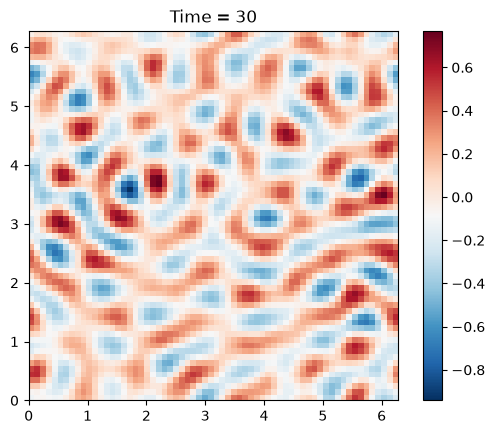

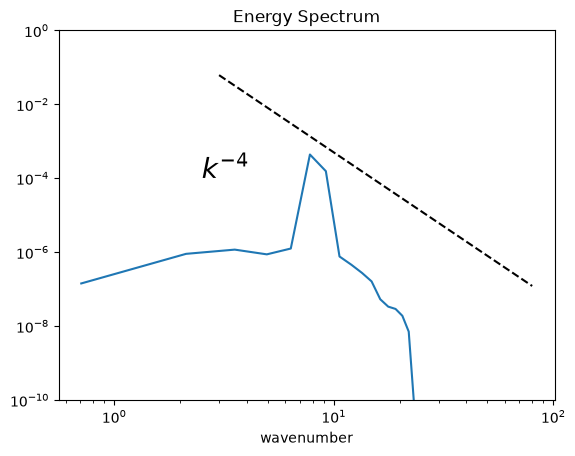

INFO: Step: 4000, Time: 4.00e+01, KE: 7.22e-04, CFL: 0.010


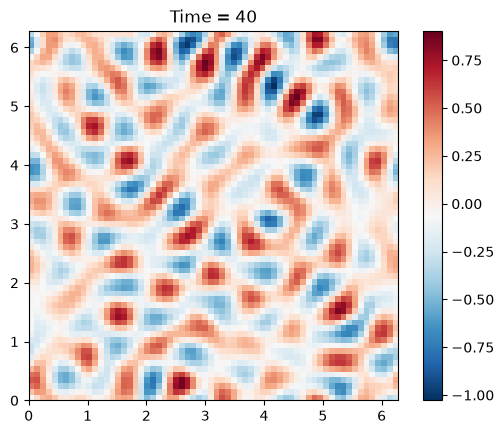

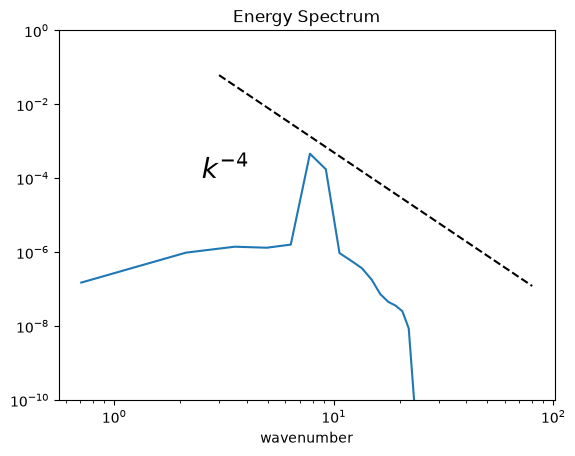

INFO: Step: 5000, Time: 5.00e+01, KE: 7.11e-04, CFL: 0.010


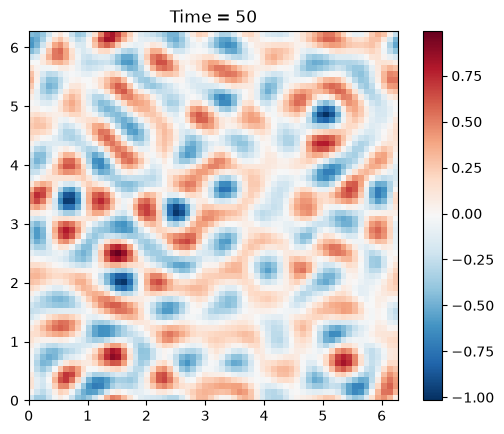

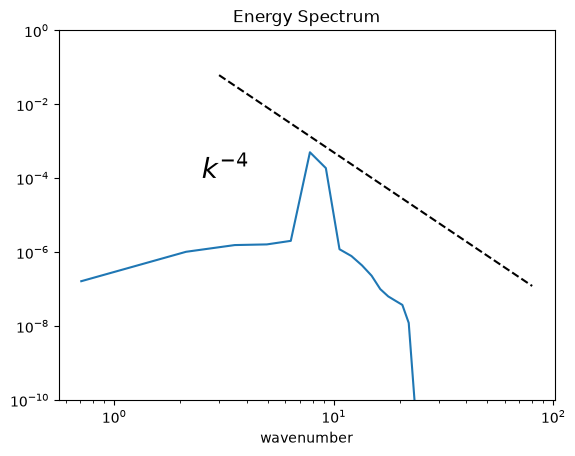

INFO: Step: 6000, Time: 6.00e+01, KE: 7.21e-04, CFL: 0.009


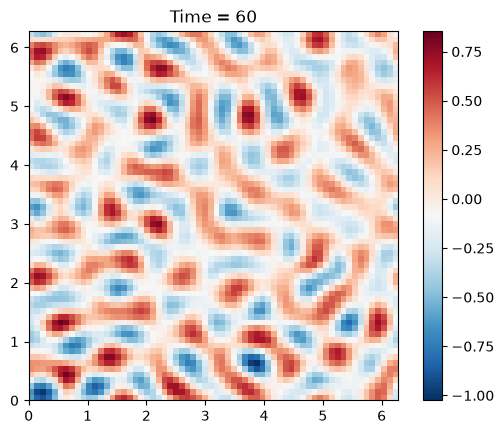

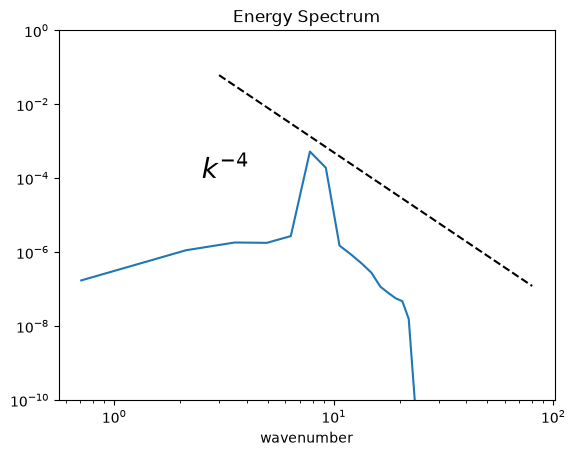

INFO: Step: 7000, Time: 7.00e+01, KE: 6.75e-04, CFL: 0.010


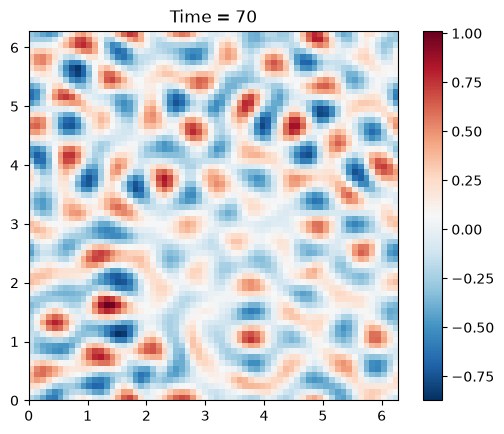

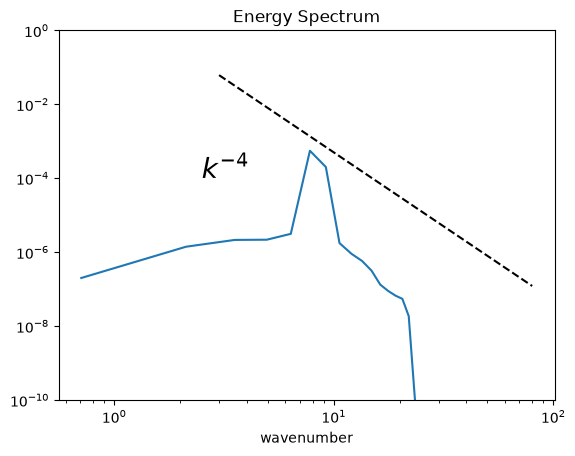

INFO: Step: 8000, Time: 8.00e+01, KE: 4.69e-04, CFL: 0.009


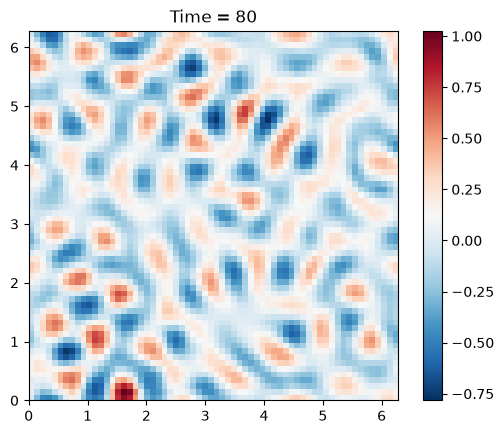

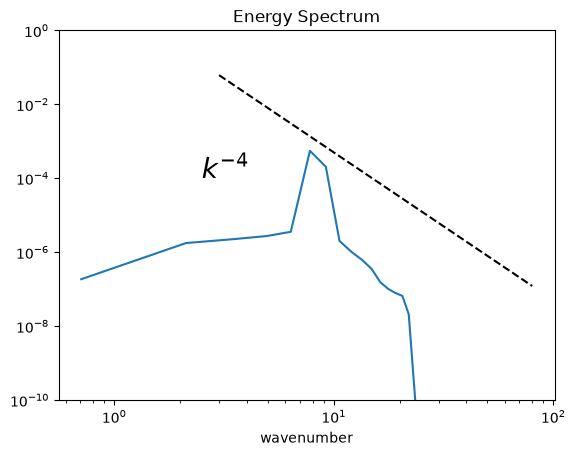

INFO: Step: 9000, Time: 9.00e+01, KE: 5.19e-04, CFL: 0.009


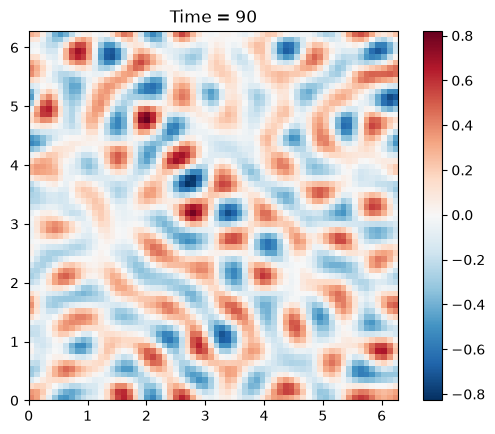

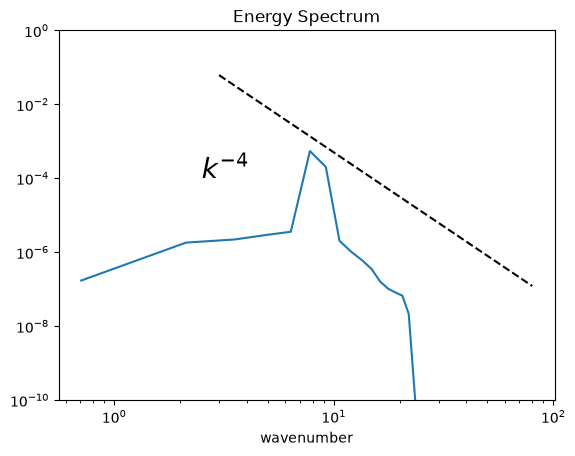

INFO: Step: 10000, Time: 1.00e+02, KE: 6.00e-04, CFL: 0.010


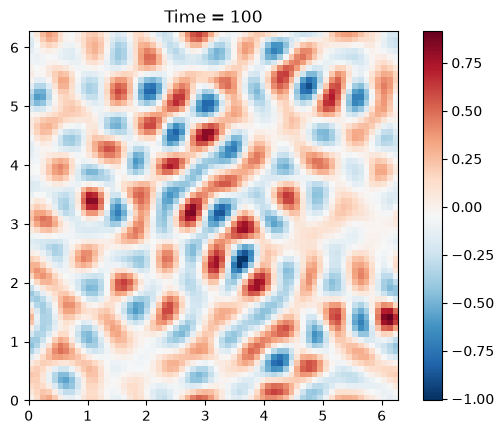

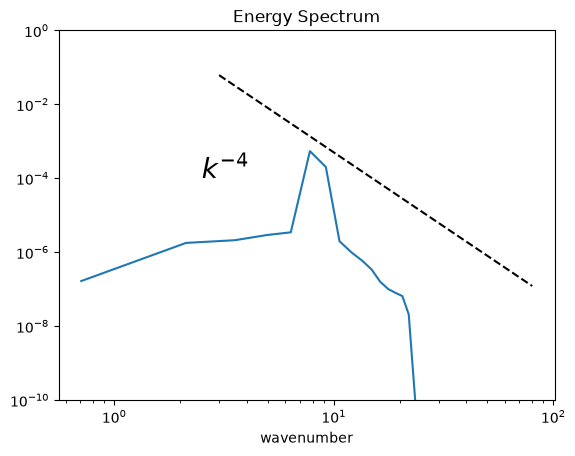

In [98]:
for _ in m.run_with_snapshots(tsnapstart=0, tsnapint=10):
    plot_q(m)

In [52]:
m.run()

INFO: Step: 1000, Time: 1.00e+01, KE: 1.42e-03, CFL: 0.014


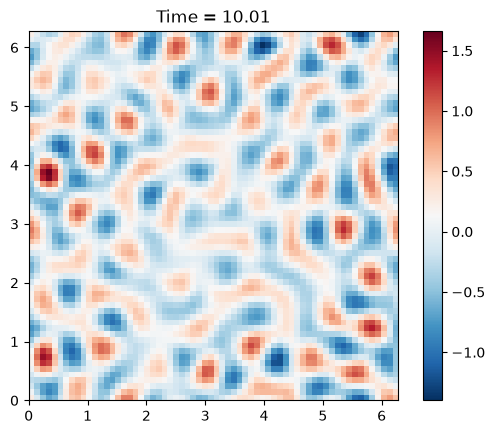

In [53]:
plot_q(m)

In [61]:
m.tmax += 10

INFO: Step: 2000, Time: 2.00e+01, KE: 2.36e-03, CFL: 0.015


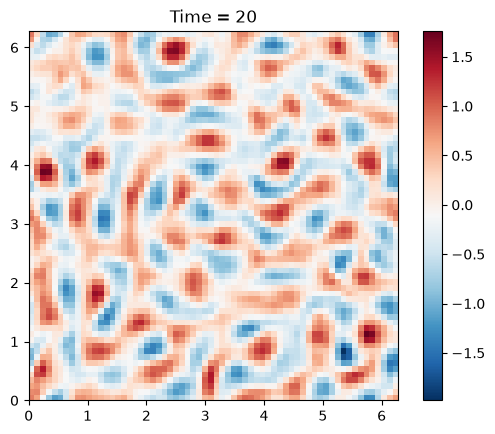

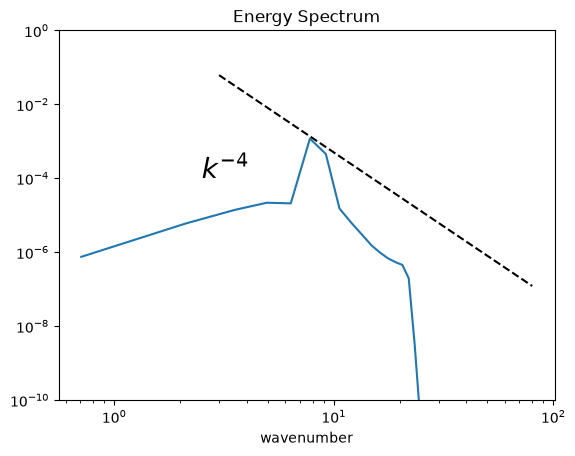

In [62]:
for _ in m.run_with_snapshots(tsnapstart=0, tsnapint=10):
    plot_q(m)